In [24]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

from torch.utils.data import DataLoader
from torchvision import models, datasets

import matplotlib.pyplot as plt
import numpy as np

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

In [25]:
## Step 1: Data Preprocessing 
# Image transformations
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),

    # Normalize for VGG19
    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])

In [26]:
# Load dataset
dataset_path = r"C:\Users\admin\tt\All-For-One\DL\dataset"
train_dataset = datasets.ImageFolder(root=f"{dataset_path}/train", transform=transform)
test_dataset = datasets.ImageFolder(root=f"{dataset_path}/test", transform=transform)

print("Classes:", train_dataset.classes)

print("Training Images:", len(train_dataset))
print("Testing Images:", len(test_dataset))

Classes: ['defect', 'notdefect']
Training Images: 172
Testing Images: 121


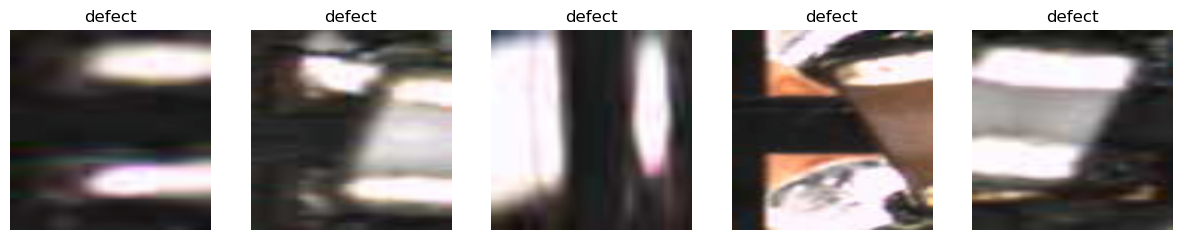

In [27]:
# Display sample input images
def show_sample_images(dataset, num_images=5):

    fig, axes = plt.subplots(1, num_images, figsize=(15,5))

    for i in range(num_images):

        image, label = dataset[i]

        # Convert tensor to image
        image = image.permute(1,2,0)

        # Unnormalize image
        image = image.numpy()

        image = (image * np.array([0.229,0.224,0.225])) + np.array([0.485,0.456,0.406])

        image = np.clip(image, 0, 1)

        axes[i].imshow(image)
        axes[i].set_title(dataset.classes[label])
        axes[i].axis("off")

    plt.show()

show_sample_images(train_dataset)

In [28]:
# Get the total number of samples in the training dataset
print(f"Total number of training samples: {len(train_dataset)}")

# Get the shape of the first image in the dataset
first_image, label = train_dataset[0]
print(f"Shape of the first image: {first_image.shape}")

Total number of training samples: 172
Shape of the first image: torch.Size([3, 224, 224])


In [29]:
# Get the total number of samples in the testing dataset


# Get the shape of the first image in the dataset



In [30]:
# Create DataLoader for batch processing
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)


In [31]:
## Step 2: Load Pretrained Model and Modify for Transfer Learning
# Load a pre-trained VGG19 model
# write your code here


from torchvision import models
from torchvision.models import VGG19_Weights

# Load pretrained VGG19
model = models.vgg19(weights=VGG19_Weights.DEFAULT)

In [32]:
# Move model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

In [33]:
from torchinfo import summary

summary(model, input_size=(1, 3, 224, 224))

Layer (type:depth-idx)                   Output Shape              Param #
VGG                                      [1, 1000]                 --
├─Sequential: 1-1                        [1, 512, 7, 7]            --
│    └─Conv2d: 2-1                       [1, 64, 224, 224]         1,792
│    └─ReLU: 2-2                         [1, 64, 224, 224]         --
│    └─Conv2d: 2-3                       [1, 64, 224, 224]         36,928
│    └─ReLU: 2-4                         [1, 64, 224, 224]         --
│    └─MaxPool2d: 2-5                    [1, 64, 112, 112]         --
│    └─Conv2d: 2-6                       [1, 128, 112, 112]        73,856
│    └─ReLU: 2-7                         [1, 128, 112, 112]        --
│    └─Conv2d: 2-8                       [1, 128, 112, 112]        147,584
│    └─ReLU: 2-9                         [1, 128, 112, 112]        --
│    └─MaxPool2d: 2-10                   [1, 128, 56, 56]          --
│    └─Conv2d: 2-11                      [1, 256, 56, 56]          29

In [34]:
# Freeze Feature Extraction Layers
# Write your code here

for param in model.features.parameters():
    param.requires_grad = False


In [35]:
# Modify Final Layer
num_classes = len(train_dataset.classes)

model.classifier[6] = nn.Linear(4096, num_classes)

In [36]:
# Move model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

In [37]:
summary(model, input_size=(1, 3, 224, 224))


Layer (type:depth-idx)                   Output Shape              Param #
VGG                                      [1, 2]                    --
├─Sequential: 1-1                        [1, 512, 7, 7]            --
│    └─Conv2d: 2-1                       [1, 64, 224, 224]         (1,792)
│    └─ReLU: 2-2                         [1, 64, 224, 224]         --
│    └─Conv2d: 2-3                       [1, 64, 224, 224]         (36,928)
│    └─ReLU: 2-4                         [1, 64, 224, 224]         --
│    └─MaxPool2d: 2-5                    [1, 64, 112, 112]         --
│    └─Conv2d: 2-6                       [1, 128, 112, 112]        (73,856)
│    └─ReLU: 2-7                         [1, 128, 112, 112]        --
│    └─Conv2d: 2-8                       [1, 128, 112, 112]        (147,584)
│    └─ReLU: 2-9                         [1, 128, 112, 112]        --
│    └─MaxPool2d: 2-10                   [1, 128, 56, 56]          --
│    └─Conv2d: 2-11                      [1, 256, 56, 56]    

In [38]:
# Include the Loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(),lr=0.0001)

In [39]:
def train_model(model, train_loader, test_loader, num_epochs=10):

    train_losses = []
    val_losses = []

    for epoch in range(num_epochs):

        # ---------------- TRAINING ----------------
        model.train()

        running_train_loss = 0.0

        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)

            # Forward pass
            outputs = model(images)

            loss = criterion(outputs, labels)

            # Backpropagation
            optimizer.zero_grad()

            loss.backward()

            optimizer.step()

            running_train_loss += loss.item()

        epoch_train_loss = running_train_loss / len(train_loader)

        train_losses.append(epoch_train_loss)

        # ---------------- VALIDATION ----------------
        model.eval()

        running_val_loss = 0.0

        with torch.no_grad():

            for images, labels in test_loader:

                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)

                loss = criterion(outputs, labels)

                running_val_loss += loss.item()

        epoch_val_loss = running_val_loss / len(test_loader)

        val_losses.append(epoch_val_loss)

        print(f'Epoch [{epoch+1}/{num_epochs}] '
              f'Train Loss: {epoch_train_loss:.4f} '
              f'Validation Loss: {epoch_val_loss:.4f}')

    # ---------------- PLOT GRAPH ----------------

    print("Name: Sai Hrishi M")
    print("Register Number: 212224240410")

    plt.figure(figsize=(8,6))

    plt.plot(
        range(1, num_epochs+1),
        train_losses,
        marker='o',
        label='Training Loss'
    )

    plt.plot(
        range(1, num_epochs+1),
        val_losses,
        marker='s',
        label='Validation Loss'
    )

    plt.xlabel("Epochs")
    plt.ylabel("Loss")

    plt.title("Training and Validation Loss")

    plt.legend()

    plt.grid(True)

    plt.show()

In [40]:
# Move model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

Epoch [1/5] Train Loss: 0.4930 Validation Loss: 0.2030
Epoch [2/5] Train Loss: 0.1350 Validation Loss: 0.1325
Epoch [3/5] Train Loss: 0.0391 Validation Loss: 0.2446
Epoch [4/5] Train Loss: 0.0098 Validation Loss: 0.2091
Epoch [5/5] Train Loss: 0.0015 Validation Loss: 0.1401
Name: Sai Hrishi M
Register Number: 212224240410


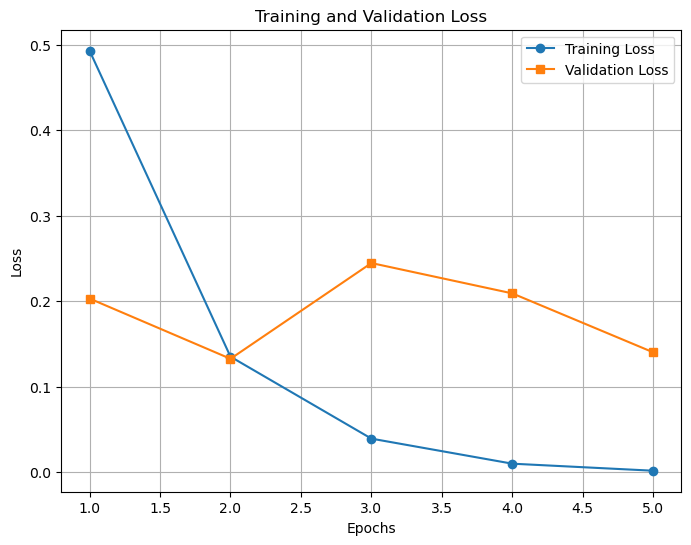

In [41]:
# Train the model
# Write your code here
train_model(model,train_loader,test_loader,num_epochs=5)

In [42]:
def test_model(model, test_loader):

    model.eval()

    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)

            correct += (predicted == labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())

            all_labels.extend(labels.cpu().numpy())

    accuracy = correct / total

    print(f"\nTest Accuracy: {accuracy*100:.2f}%")

    # ---------------- CONFUSION MATRIX ----------------

    cm = confusion_matrix(all_labels, all_preds)

    print("Name: Sai Hrishi M")
    print("Register Number: 212224240140")

    plt.figure(figsize=(8,6))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=train_dataset.classes,
        yticklabels=train_dataset.classes
    )

    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.title("Confusion Matrix")

    plt.show()

    # ---------------- CLASSIFICATION REPORT ----------------

    print("Classification Report:\n")

    print(classification_report(
        all_labels,
        all_preds,
        target_names=train_dataset.classes
    ))


Test Accuracy: 94.21%
Name: Sai Hrishi M
Register Number: 212224240140


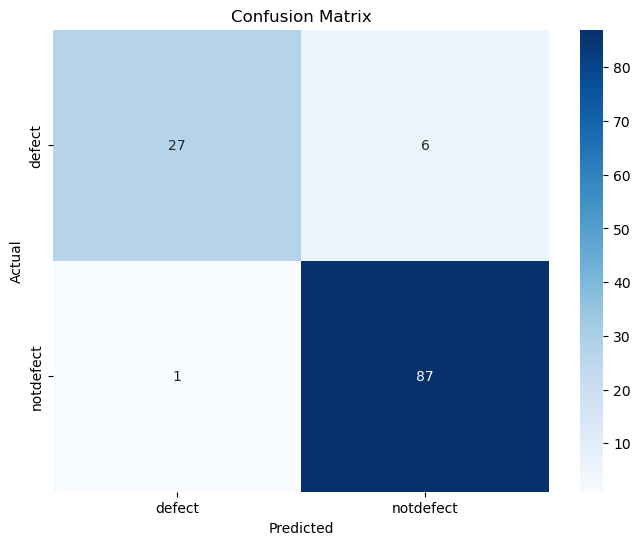

Classification Report:

              precision    recall  f1-score   support

      defect       0.96      0.82      0.89        33
   notdefect       0.94      0.99      0.96        88

    accuracy                           0.94       121
   macro avg       0.95      0.90      0.92       121
weighted avg       0.94      0.94      0.94       121



In [43]:
# Evaluate the model
# write your code here
test_model(model, test_loader)

In [44]:
## Step 5: Predict on a Single Image and Display It
def predict_image(model, image_index, dataset):

    model.eval()

    image, label = dataset[image_index]

    with torch.no_grad():

        image_tensor = image.unsqueeze(0).to(device)

        output = model(image_tensor)

        _, predicted = torch.max(output, 1)

    class_names = dataset.classes

    # Convert image for display
    image_display = image.permute(1,2,0).numpy()

    image_display = (
        image_display * np.array([0.229,0.224,0.225])
    ) + np.array([0.485,0.456,0.406])

    image_display = np.clip(image_display, 0, 1)

    plt.figure(figsize=(4,4))

    plt.imshow(image_display)

    plt.title(
        f'Actual: {class_names[label]}\n'
        f'Predicted: {class_names[predicted.item()]}'
    )

    plt.axis("off")

    plt.show()

    print(
        f'Actual: {class_names[label]} '
        f'Predicted: {class_names[predicted.item()]}'
    )

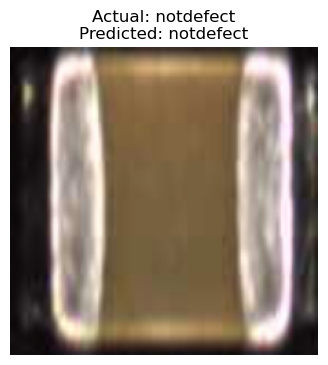

Actual: notdefect Predicted: notdefect


In [45]:
# Example Prediction
predict_image(model, image_index=55, dataset=test_dataset)


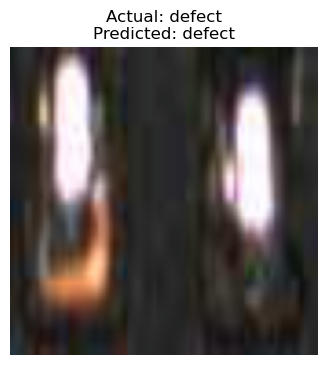

Actual: defect Predicted: defect


In [46]:
#Example Prediction
predict_image(model, image_index=25, dataset=test_dataset)